# GraphCast demo: next-day prediction

Run **GraphCast_small** (1° resolution, 13 pressure levels) to predict the next 24 hours of weather (4 x 6 h steps).

- **Model weights and normalization stats** are downloaded from GCS bucket dm_graphcast when not already present.
- **Data:** Uses the project ERA5 Zarr via open_graphcast_era5 (last 6 time steps).

**Requirements:** graphcast, JAX, Haiku, xarray. Optional google-cloud-storage for download.

**GPU:** By default the notebook uses CPU (avoids `CUDA_ERROR_NO_DEVICE` when no GPU is visible). To use GPU: (1) run the notebook on a GPU node (e.g. `USE_GPU=1 srun --gres=gpu:1 --pty jupyter notebook`), and (2) set env `USE_GPU=1` before starting the kernel. Run the GPU-check cell after the imports to confirm.

### Optional: force CPU
If you get `CUDA_ERROR_NO_DEVICE`, run the cell below then **Kernel → Restart & Run All** to use CPU only.

In [1]:
import socket
import subprocess

# 1. Where is this kernel running?
print("Hostname (kernel runs on):", socket.gethostname())

# 2. Does this machine see a GPU? (optional; needs nvidia-smi)
try:
    out = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, timeout=5)
    print("GPUs visible to this node:", out.stdout.strip() or out.stderr.strip() or "none")
except Exception as e:
    print("nvidia-smi check:", e)

# 3. Does JAX see the GPU?
import jax
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

Hostname (kernel runs on): della-l04g4
GPUs visible to this node: GPU 0: NVIDIA A100 80GB PCIe (UUID: GPU-83edc80a-b6d3-1c4a-8a67-aac203a76668)
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [2]:
import os; os.environ["USE_GPU"] = "1"
os.environ["JAX_PLATFORMS"] = "GPU"

In [3]:
import os

import dataclasses
import functools
import sys
from pathlib import Path

import numpy as np
import xarray

from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
import haiku as hk
import jax

try:
    from google.cloud import storage
except ImportError:
    storage = None  # pip install google-cloud-storage for download

# Project root (notebook may run from scripts/ or project root)
ROOT = Path.cwd()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [4]:
# Check if JAX sees a GPU (run this after the imports cell above)
import jax
print("JAX backend:", jax.default_backend())  # 'gpu' or 'cuda' = GPU, 'cpu' = CPU only
print("Devices:", jax.devices())

JAX backend: gpu
Devices: [CudaDevice(id=0)]


In [5]:
DATA_DIR = ROOT / "data/graphcast/graphcast"
PARAMS_DIR = DATA_DIR / "params"
STATS_DIR = DATA_DIR / "stats"
# dataset_dir = DATA_DIR / "dataset/source-era5_wb13_latest-1y_res-1.0_levels-13_steps-all.zarr"
dataset_dir = DATA_DIR / "dataset/source-era5_cds_rolling-last30d_res-1.0_levels-13_steps-04.nc"
DIR_PREFIX = "graphcast/"

# GraphCast_small params filename (set to None to auto-detect from GCS list)
PARAMS_FILENAME = None

if PARAMS_FILENAME is not None:
    params_path = PARAMS_DIR / PARAMS_FILENAME
else:
    params_path = None

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("dataset_dir exists:", dataset_dir.exists())

ROOT: /scratch/gpfs/DABANIN/iv9432/Weather_global
DATA_DIR: /scratch/gpfs/DABANIN/iv9432/Weather_global/data/graphcast/graphcast
dataset_dir exists: True


In [6]:
PARAMS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

STATS_FILES = ["diffs_stddev_by_level.nc", "mean_by_level.nc", "stddev_by_level.nc"]
stats_complete = all((STATS_DIR / f).exists() for f in STATS_FILES)

# If params_path not set, discover existing params file in PARAMS_DIR (e.g. manually downloaded)
if params_path is None:
    existing = list(PARAMS_DIR.glob("*small*.npz")) or list(PARAMS_DIR.glob("*.npz"))
    if existing:
        params_path = existing[0]

need_download = (params_path is None or not params_path.exists()) or not stats_complete

def _download_url(url, path, desc="file"):
    import urllib.request
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "GraphCast-demo"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            path.write_bytes(resp.read())
        print(f"Downloaded {desc}: {path.name}")
        return True
    except Exception as e:
        print(f"Could not download {url}: {e}")
        return False

GCS_BASE = "https://storage.googleapis.com/dm_graphcast/graphcast"
# Known GraphCast_small params filenames to try (bucket listing may use different naming)
PARAMS_CANDIDATES = [
    "params_GraphCast_small-ERA5_1979-2015-resolution_1.0-pressure_levels_13-mesh_size_2.npz",
    "GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5.npz",
]

if need_download and storage is not None:
    gcs_client = storage.Client.create_anonymous_client()
    gcs_bucket = gcs_client.get_bucket("dm_graphcast")

    blob_names = [
        b.name.removeprefix(DIR_PREFIX + "params/")
        for b in gcs_bucket.list_blobs(prefix=DIR_PREFIX + "params/")
        if b.name.removeprefix(DIR_PREFIX + "params/")
    ]
    small_options = [n for n in blob_names if "small" in n.lower()]
    best = [n for n in small_options if "1.0" in n and "13" in n]
    chosen = (best or small_options)[0] if (best or small_options) else None
    if chosen is None:
        raise FileNotFoundError(
            "No GraphCast_small params found in dm_graphcast. Available (first 5): "
            + str(blob_names[:5])
        )
    params_path = PARAMS_DIR / chosen

    if not params_path.exists():
        print("Downloading params:", chosen)
        blob = gcs_bucket.blob(DIR_PREFIX + "params/" + chosen)
        blob.download_to_filename(str(params_path))

    for fname in STATS_FILES:
        local = STATS_DIR / fname
        if not local.exists():
            print("Downloading stats:", fname)
            gcs_bucket.blob(DIR_PREFIX + "stats/" + fname).download_to_filename(str(local))
    print("Params path:", params_path)
elif need_download and storage is None:
    # No google-cloud-storage (e.g. no pip network): try public HTTPS with urllib
    import urllib.parse
    downloaded_params = False
    if params_path is None or not params_path.exists():
        for candidate in PARAMS_CANDIDATES:
            url = f"{GCS_BASE}/params/{urllib.parse.quote(candidate)}"
            path = PARAMS_DIR / candidate
            if _download_url(url, path, "params"):
                params_path = path
                downloaded_params = True
                break
        if not downloaded_params and (params_path is None or not params_path.exists()):
            raise FileNotFoundError(
                "Could not download params (no network or wrong URL). Install google-cloud-storage "
                "where pip works, or download manually from "
                "https://console.cloud.google.com/storage/browser/dm_graphcast/graphcast/params "
                "and place the GraphCast_small .npz file in:\n  " + str(PARAMS_DIR)
            )
    for fname in STATS_FILES:
        local = STATS_DIR / fname
        if not local.exists():
            if not _download_url(f"{GCS_BASE}/stats/{fname}", local, fname):
                raise FileNotFoundError(
                    f"Could not download {fname}. Place it manually in:\n  " + str(STATS_DIR)
                )
    if params_path is not None:
        print("Params path:", params_path)
else:
    if params_path is None:
        existing = list(PARAMS_DIR.glob("*small*.npz")) or list(PARAMS_DIR.glob("*.npz"))
        if existing:
            params_path = existing[0]
        else:
            raise FileNotFoundError("No params file found in " + str(PARAMS_DIR))
    print("Using existing params:", params_path)

Using existing params: /scratch/gpfs/DABANIN/iv9432/Weather_global/data/graphcast/graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz


In [7]:
with open(params_path, "rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
print("Model:", ckpt.description)
print("model_config.resolution:", model_config.resolution)
print("Pressure levels:", len(task_config.pressure_levels))

Model: 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.

model_config.resolution: 1.0
Pressure levels: 13


In [8]:
diffs_stddev_by_level = xarray.open_dataset(STATS_DIR / "diffs_stddev_by_level.nc").compute()
mean_by_level = xarray.open_dataset(STATS_DIR / "mean_by_level.nc").compute()
stddev_by_level = xarray.open_dataset(STATS_DIR / "stddev_by_level.nc").compute()
print("Normalization stats loaded.")

Normalization stats loaded.


In [9]:
from src.data.graphcast_dataset import open_graphcast_era5

# Last 6 steps: 2 for input (t-6h, t0), 2 for next-day targets (6h, 12h, 18h, 24h)
ds = open_graphcast_era5(dataset_dir, time_slice=slice(-6, None))
ds = ds.compute()

# GraphCast data_utils expects time + datetime coords; convert hours since epoch to datetime64
import pandas as pd
if np.issubdtype(ds["time"].dtype, np.integer) or ds["time"].dtype.kind in "iu":
    times = pd.to_datetime(ds["time"].values, unit="h", origin="1959-01-01")
    ds = ds.assign_coords(time=("time", times))
# add_derived_vars requires "datetime" with same dims as data (batch, time) for progress features
if "batch" in ds.dims:
    dt = xarray.DataArray(ds["time"].values, dims=["time"]).expand_dims(batch=ds.sizes["batch"])
    ds = ds.assign_coords(datetime=dt)
else:
    ds = ds.assign_coords(datetime=("time", ds["time"].values))

print("Dataset time steps:", ds.sizes["time"])
print("Time coord (first, last):", ds["time"].values[0], ds["time"].values[-1])

Dataset time steps: 6
Time coord (first, last): 2026-02-14T18:00:00.000000000 2026-02-16T00:00:00.000000000


In [10]:
inputs, targets, forcings = data_utils.extract_inputs_targets_forcings(
    ds,
    target_lead_times=slice("6h", "24h"),
    **dataclasses.asdict(task_config),
)

# GraphCast expects static inputs (e.g. geopotential_at_surface, land_sea_mask)
# to have no time dimension. Our dataset may give them (batch, time, lat, lon);
# collapse to (batch, lat, lon) by taking the first timestep.
from graphcast import graphcast as graphcast_module
for name in getattr(graphcast_module, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
    if name in inputs and "time" in inputs[name].dims:
        inputs = inputs.assign({name: inputs[name].isel(time=0, drop=True)})

print("Inputs:", inputs.sizes)
print("Targets:", targets.sizes)
print("Forcings:", forcings.sizes)

Inputs: {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Targets: {'batch': 1, 'time': 4, 'lat': 181, 'lon': 360, 'level': 13}
Forcings: {'batch': 1, 'time': 4, 'lat': 181, 'lon': 360}


In [11]:
def construct_wrapped_graphcast(model_config, task_config):
    predictor = graphcast.GraphCast(model_config, task_config)
    predictor = casting.Bfloat16Cast(predictor)
    predictor = normalization.InputsAndResiduals(
        predictor,
        diffs_stddev_by_level=diffs_stddev_by_level,
        mean_by_level=mean_by_level,
        stddev_by_level=stddev_by_level,
    )
    predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
    return predictor


@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    return predictor(inputs, targets_template=targets_template, forcings=forcings)


def with_configs(fn):
    return functools.partial(fn, model_config=model_config, task_config=task_config)


def with_params(fn):
    return functools.partial(fn, params=params, state=state)


def drop_state(fn):
    return lambda **kw: fn(**kw)[0]


run_forward_jitted = drop_state(with_params(jax.jit(with_configs(run_forward.apply))))
print("Jitted predictor ready.")

Jitted predictor ready.


In [15]:
# Ensure static inputs have no time dim (required by GraphCast; safe if already fixed in data cell).
for name in getattr(graphcast, "STATIC_VARS", ("geopotential_at_surface", "land_sea_mask")):
    if name in inputs and "time" in inputs[name].dims:
        inputs = inputs.assign({name: inputs[name].isel(time=0, drop=True)})

assert model_config.resolution in (0, 360.0 / inputs.sizes["lon"]), (
    "Model resolution doesn't match data resolution."
)

predictions = rollout.chunked_prediction(
    run_forward_jitted,
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets * np.nan,
    forcings=forcings,
)
print("Predictions:", predictions.sizes)
predictions

/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_inputs = inputs.dims['time']
/home/iv9432/.conda/envs/graphcast311/lib/python3.11/site-packages/graphcast/rollout.py:400: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more con

Predictions: Frozen({'time': 4, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13})


<xarray.Dataset> Size: 87MB
Dimensions:                  (time: 4, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 32B 06:00:00 ... 1 days 0...
  * batch                    (batch) int64 8B 0
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * level                    (level) int32 52B 50 100 150 200 ... 850 925 1000
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 1MB 2.205 ... 1.918
    10m_v_component_of_wind  (time, batch, lat, lon) float32 1MB -1.679 ... 0...
    2m_temperature           (time, batch, lat, lon) float32 1MB 247.1 ... 235.9
    geopotential             (time, batch, level, lat, lon) float32 14MB 1.91...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 1MB 1.027e+05 .....
    specific_humidity        (time, batch, level, lat, lon) float32 14MB 3.32...
    temperature              (time, batch, level, lat, lon) float32 14MB 207....
    total_precipitation_6hr  (time, batch, lat, lon) float32 1MB -0.0002002 ....
    u_component_of_wind      (time, batch, level, lat, lon) float32 14MB -4.0...
    v_component_of_wind      (time, batch, level, lat, lon) float32 14MB -16....
    vertical_velocity        (time, batch, level, lat, lon) float32 14MB 0.00...

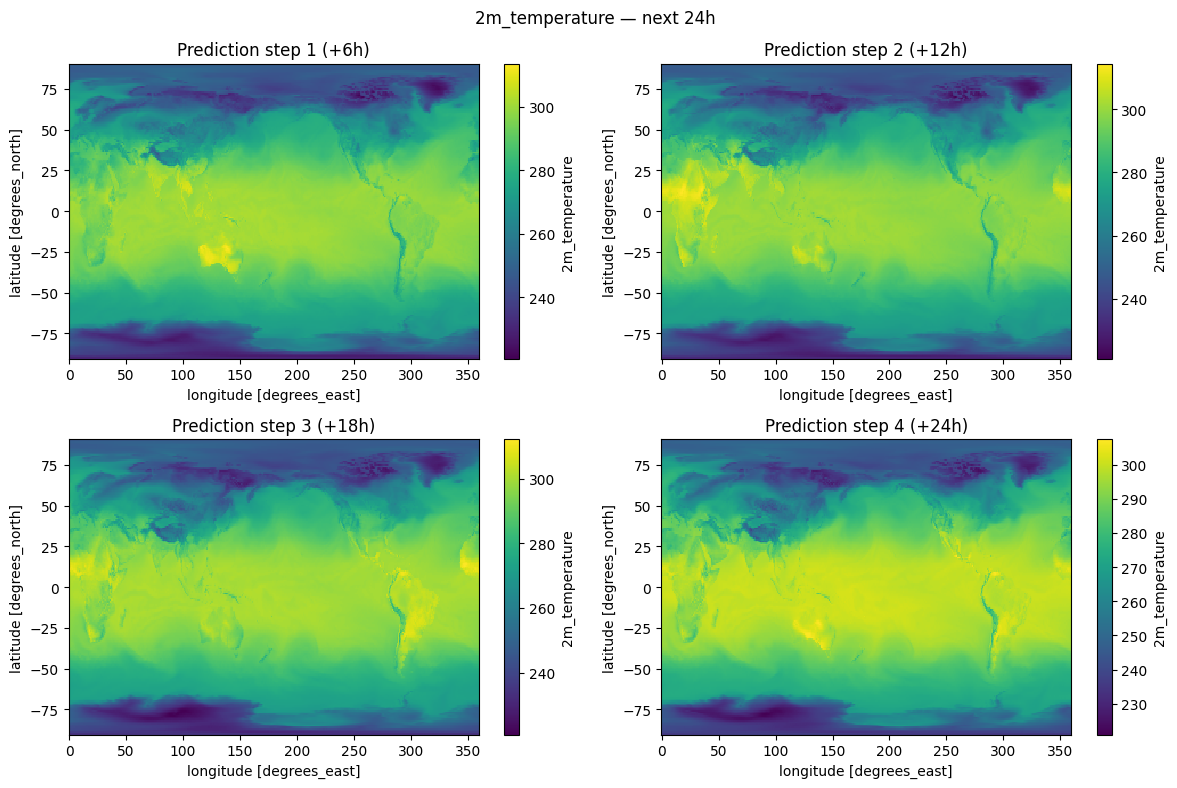

In [ ]:
import matplotlib.pyplot as plt

variable = "2m_temperature"
n_steps = predictions.sizes.get("time", 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i in range(min(4, n_steps)):
    ax = axes[i]
    pred = predictions[variable].isel(batch=0, time=i)
    if "level" in pred.dims:
        pred = pred.isel(level=0)
    pred.plot(ax=ax, cmap="viridis")
    ax.set_title(f"Prediction step {i + 1} (+{(i + 1) * 6}h)")
plt.suptitle(f"{variable} — next 24h")
plt.tight_layout()
plt.show()